In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df['Gender'].value_counts()


,count
Gender,
Female,112
Male,88


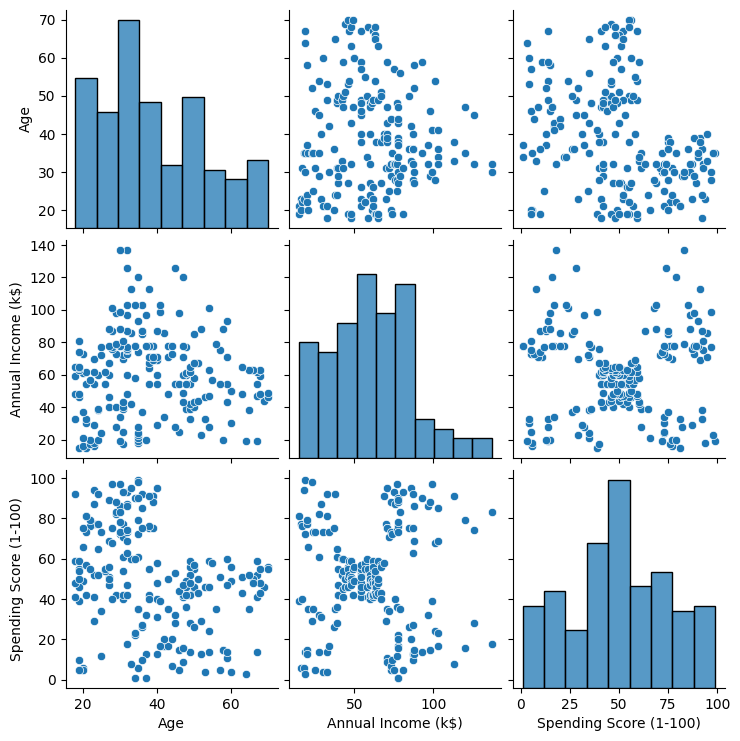

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()


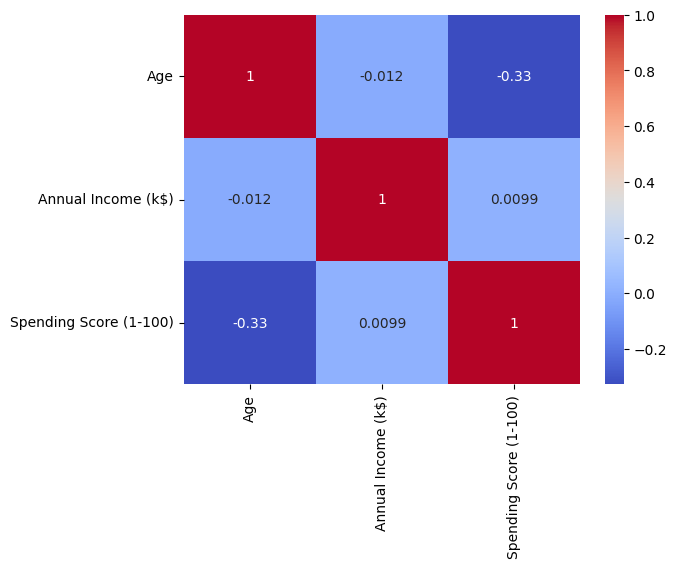

In [ ]:
sns.heatmap(df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr(), annot=True, cmap='coolwarm')
plt.show()


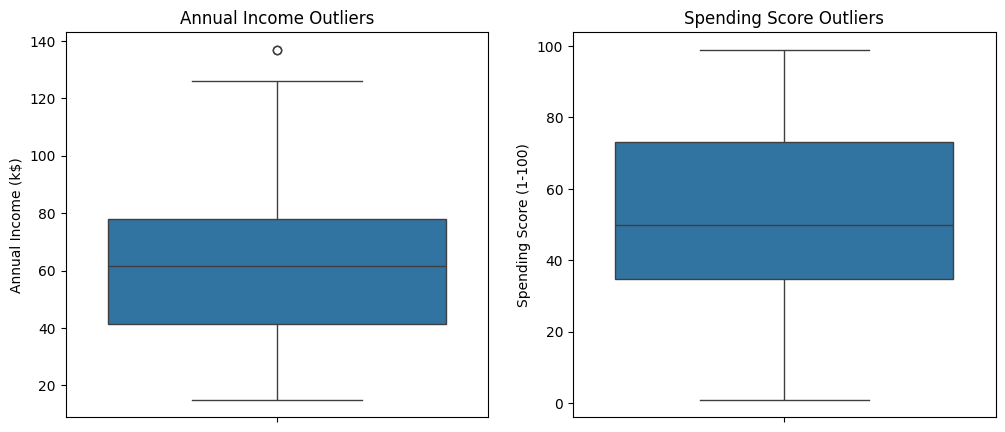

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, y='Annual Income (k$)')
plt.title("Annual Income Outliers")

plt.subplot(1,2,2)
sns.boxplot(data=df, y='Spending Score (1-100)')
plt.title("Spending Score Outliers")

plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]   # show first 5 scaled rows


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

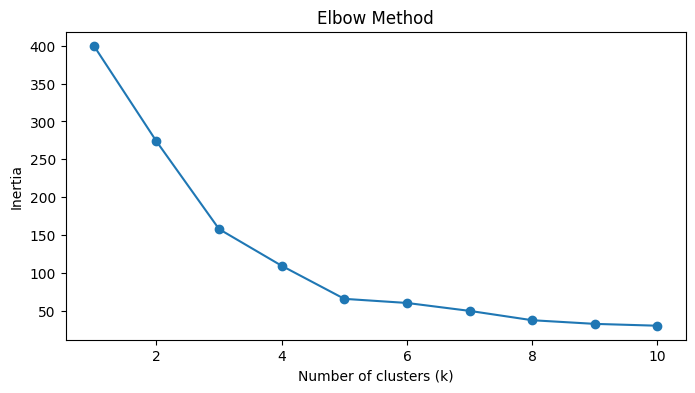

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score}")


k = 2, Silhouette Score = 0.3973270007887498
k = 3, Silhouette Score = 0.46658474419000145
k = 4, Silhouette Score = 0.49434988482196784
k = 5, Silhouette Score = 0.5546571631111091
k = 6, Silhouette Score = 0.5138257534676561
k = 7, Silhouette Score = 0.50200146805547
k = 8, Silhouette Score = 0.4550112502601921
k = 9, Silhouette Score = 0.4566624374485964
k = 10, Silhouette Score = 0.44475993501732874


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


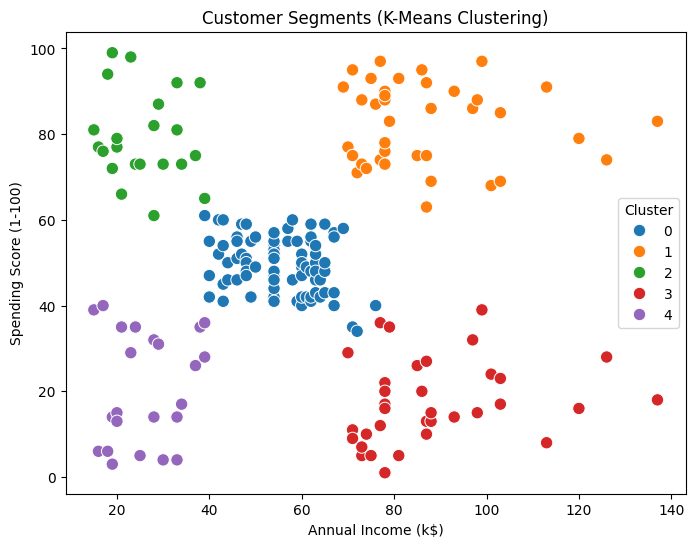

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='tab10',
    s=80
)
plt.title("Customer Segments (K-Means Clustering)")
plt.show()


In [ ]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Count'] = df['Cluster'].value_counts()
cluster_summary


,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,
0,55.296296,49.518519,81
1,86.538462,82.128205,39
2,25.727273,79.363636,22
3,88.200000,17.114286,35
4,26.304348,20.913043,23
